In [1]:
# will discuss regarding key ridge points

In [2]:
import numpy as np
import pandas as pd

In [3]:
from sklearn.datasets import load_diabetes

In [4]:
data = load_diabetes()

In [5]:
df = pd.DataFrame(data.data, columns= data.feature_names)

In [6]:
df['Target'] = data.target

In [7]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
df.shape

(442, 11)

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 0:-1], df['Target'], test_size= 0.2, random_state= 20)

In [11]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
171,-0.020045,-0.044642,-0.046085,-0.098627,-0.075870,-0.059873,-0.017629,-0.039493,-0.051404,-0.046641
388,0.052606,0.050680,-0.024529,0.056301,-0.007073,-0.005072,-0.021311,-0.002592,0.026717,-0.038357
268,0.063504,0.050680,0.088642,0.070072,0.020446,0.037517,-0.050764,0.071210,0.029297,0.073480
31,-0.023677,-0.044642,-0.065486,-0.081413,-0.038720,-0.053610,0.059685,-0.076395,-0.037129,-0.042499
427,-0.034575,0.050680,0.005650,-0.005670,-0.073119,-0.062691,-0.006584,-0.039493,-0.045424,0.032059


In [12]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [13]:
coefs = []
r2_scores = []

for i in [0, 1, 10, 100, 1000, 10000]:
  ridge = Ridge(i)
  ridge.fit(X_train, y_train)
  coefs.append(ridge.coef_.tolist())
  r2_scores.append(r2_score(y_test, ridge.predict(X_test)))

In [14]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Alpha = 10000, r2_score = -0.027559190758358554')

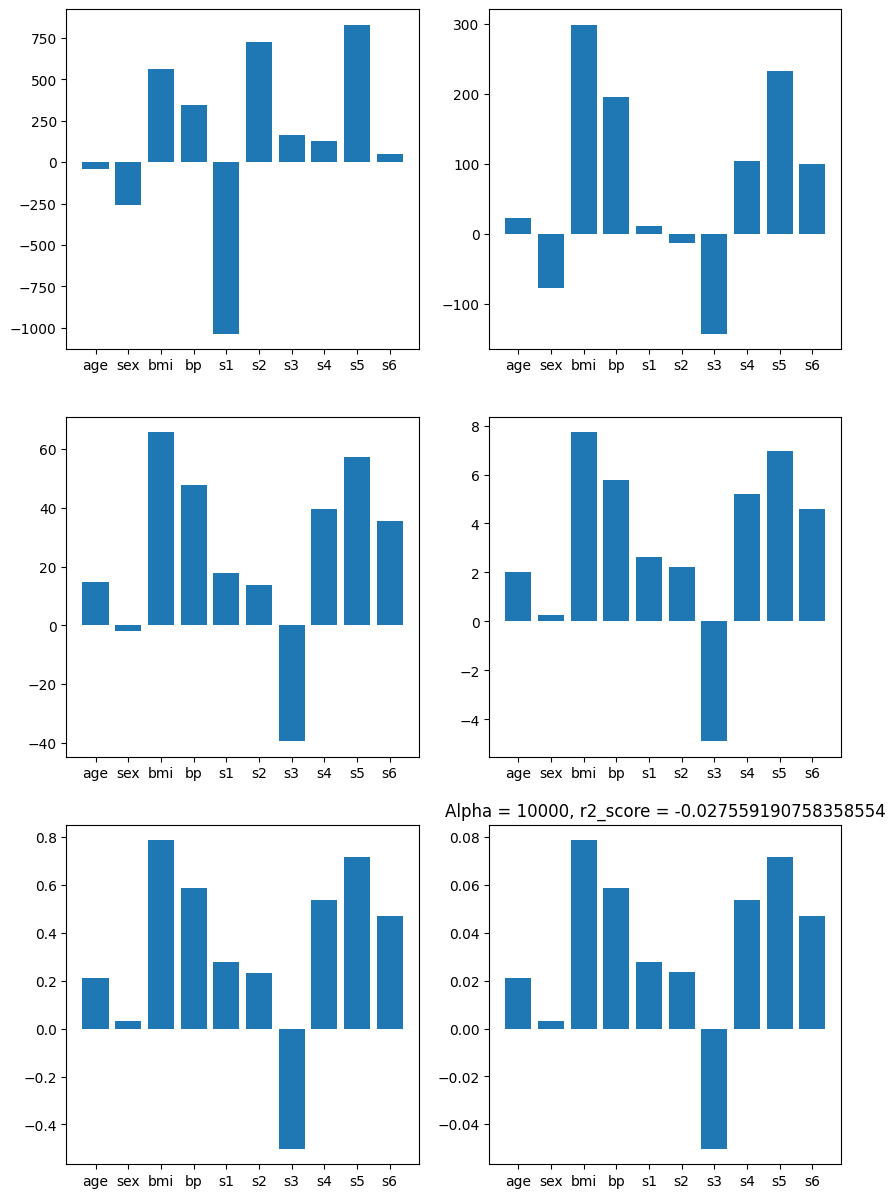

In [15]:
# effect of lamda on coefficients
fig, ax = plt.subplots(3, 2, figsize = (10, 15))

ax[0, 0].bar(data.feature_names, coefs[0])
plt.title(f"Alpha = {0}, r2_score = {r2_scores[0]}")

ax[0, 1].bar(data.feature_names, coefs[1])
plt.title(f"Alpha = {1}, r2_score = {r2_scores[1]}")

ax[1, 0].bar(data.feature_names, coefs[2])
plt.title(f"Alpha = {10}, r2_score = {r2_scores[2]}")

ax[1, 1].bar(data.feature_names, coefs[3])
plt.title(f"Alpha = {100}, r2_score = {r2_scores[3]}")

ax[2, 0].bar(data.feature_names, coefs[4])
plt.title(f"Alpha = {1000}, r2_score = {r2_scores[4]}")

ax[2, 1].bar(data.feature_names, coefs[5])
plt.title(f"Alpha = {10000}, r2_score = {r2_scores[5]}")

In [16]:
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
coefs = []
for i in alphas:
  ridge = Ridge(i)
  ridge.fit(X_train, y_train)
  coefs.append(ridge.coef_.tolist())

In [17]:
input_array = np.array(coefs)

In [18]:

# larger coeffiecnits decreases faster
coef_df = pd.DataFrame(input_array, columns= data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-40.432056,-255.596944,561.211521,346.660737,-1034.954276,726.216366,167.039617,127.476064,830.266293,51.240135
0.0001,-40.277594,-255.438433,561.308988,346.605119,-1020.214996,714.381000,160.699561,125.970428,824.555471,51.336193
0.0010,-39.043748,-254.150362,562.013250,346.140461,-904.621186,621.507166,111.101572,114.344868,779.672723,52.115985
0.0100,-32.998904,-246.828272,562.118086,342.892670,-430.820690,238.936627,-87.192093,73.893105,591.685599,56.513325
0.1000,-16.706815,-212.635813,520.382542,318.874453,-81.527632,-39.749051,-196.893364,87.327572,413.261257,75.128234
1.0000,22.795949,-77.444457,299.212879,196.158167,11.813063,-13.094711,-142.051067,104.946231,232.791550,100.302414
10.0000,14.709666,-1.883797,65.722124,47.728603,17.836119,13.694300,-39.438946,39.540772,57.366987,35.607307
100.0000,2.028249,0.256991,7.722821,5.757727,2.643812,2.222720,-4.892641,5.202916,6.981323,4.575749
1000.0000,0.210235,0.031917,0.786843,0.588421,0.276102,0.234009,-0.501581,0.536868,0.714257,0.470849
